In [ ]:
##### Initial import and setup #####
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# Ignore warnings for cleaner output
import warnings

warnings.filterwarnings("ignore", "Workbook contains no default style", UserWarning)

In [ ]:
# Load data/EUROSTAT_COMEXT.csv into a DataFrame
comext_df = pd.read_csv("data/EUROSTAT_COMEXT.csv")

# Select relevant columns
selected_columns = [
    "reporter",
    "partner",
    "product",
    "PRODUCT",
    "flow",
    "FLOW",
    "indicators",
    "TIME_PERIOD",
    "OBS_VALUE",
]
eurostat_df = comext_df[selected_columns].copy()

In [ ]:
# TEMP: Filter out "product" starting with 87
eurostat_df = eurostat_df[~eurostat_df["product"].astype(str).str.startswith("87")]

# Display unique values for product and corresponding PRODUCT as dictionary
product_dict = dict(zip(eurostat_df["product"], eurostat_df["PRODUCT"]))
# print("Unique products and their corresponding PRODUCT codes:")
# for product, code in product_dict.items():
#     print(f"{product}: {code}")


# Only focusing on "final_LED" products for now, which corresponds to product code 853950
# Categorymapping based on product codes
category_mapping = {
    # 'raw_Ga': 81129289,
    # 'intermediate_LED' : 854140,
    # 'intermediate_IC' : [854231, 854232, 854233, 854239],
    "final_LED": 853950,
}

# Create some data structure to hold categorical text, product code, lifespan, and material intensity
product_info = {
    "final_LED": {
        "product": 853950,
        "lifespan_years": 6,  # Example lifespan for final LED products
        "market_share": 1,
        "material_intensity_Ga": 0.000014,
    },
}

In [ ]:
def build_imp_exp_table(df, product_code, partner="EXT_EU27_2020"):
    """Build a yearly import/export/net-flow table (in kg) for a given product code.

    Filters and pivots dataframe.

    Args:
        df: COMEXT-format DataFrame containing at least the columns
            "product", "indicators", "partner", "FLOW", "TIME_PERIOD",
            and "OBS_VALUE".
        product_code: Product code (as used in the "product" column) to
            filter the data on.
        partner: Trade partner code to filter on. Defaults to
            "EXT_EU27_2020" (extra-EU27 trade).

    Returns:
        DataFrame: One row per TIME_PERIOD with columns "TIME_PERIOD",
        "Exports_kg", "Imports_kg", and "Net_Flow_kg" (Imports - Exports).
    """
    indicator = "QUANTITY_IN_100KG"
    scale_to_kg = 100
    # Filter relevant records
    filtered_df = df[
        (df["product"] == product_code)
        & (df["indicators"] == indicator)
        & (df["partner"] == partner)
    ].copy()

    # Convert unit (e.g., 100kg -> kg)
    filtered_df["OBS_VALUE_KG"] = filtered_df["OBS_VALUE"] * scale_to_kg

    # Aggregate by year and flow
    flow_df = filtered_df.groupby(["TIME_PERIOD", "FLOW"], as_index=False)[
        "OBS_VALUE_KG"
    ].sum()

    # Pivot to import/export columns
    pivot_df = flow_df.pivot(
        index="TIME_PERIOD", columns="FLOW", values="OBS_VALUE_KG"
    ).fillna(0)

    # Ensure both columns exist
    for col in ["EXPORT", "IMPORT"]:
        if col not in pivot_df.columns:
            pivot_df[col] = 0

    pivot_df = pivot_df.rename(columns={"EXPORT": "Exports_kg", "IMPORT": "Imports_kg"})
    pivot_df["Net_Flow_kg"] = pivot_df["Imports_kg"] - pivot_df["Exports_kg"]
    pivot_df = pivot_df.reset_index()

    # return filtered_df, flow_df, pivot_df
    return pivot_df


def plot_imp_exp_table(df, display_product_name):
    """Line-plot for inspection of exp_table
    Shows a line for Exports_kg, Imports_kg, and Net_Flow_kg over TIME_PERIOD for a product.

    Args:
        df: DataFrame with columns "TIME_PERIOD", "Exports_kg",
            "Imports_kg", and "Net_Flow_kg" (e.g. as returned by
            build_imp_exp_table or translate_to_Ga_MI).
        display_product_name: Display name of the product, used in the plot title.

    Returns:
        None: Displays the plot via matplotlib; does not return a value.
    """
    # Plot exports, imports, and net flow over time for final LED products
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=df,
        x="TIME_PERIOD",
        y="Exports_kg",
        marker="o",
        label="Exports (kg/y)",
    )
    sns.lineplot(
        data=df,
        x="TIME_PERIOD",
        y="Imports_kg",
        marker="o",
        label="Imports (kg/y)",
    )
    sns.lineplot(
        data=df,
        x="TIME_PERIOD",
        y="Net_Flow_kg",
        marker="o",
        label="Net Flow (kg/y)",
    )
    plt.title(f"{display_product_name} - EU\nExports, Imports, and Net Flow Over Time")
    plt.xlabel("Year")
    plt.ylabel("Quantity (kg/y)")
    plt.xticks(
        rotation=45, ticks=df["TIME_PERIOD"].unique()
    )  # Set x ticks format to integer years and rotate
    plt.legend()
    plt.grid()
    plt.show()


def translate_to_Ga_MI(df, material_intensity_Ga):
    """Scale an Imports/Exports/Net_Flow (kg) table by a gallium material intensity factor.

    Args:
        df: DataFrame (imp_exp_table) with columns "Imports_kg", "Exports_kg",
            and "Net_Flow_kg" (e.g. as returned by build_imp_exp_table).
        material_intensity_Ga: Mass fraction (kg Ga per kg product) used to
            convert product mass flows into gallium mass flows.

    Returns:
        pd.DataFrame: Copy of df with "Imports_kg", "Exports_kg",
        and "Net_Flow_kg" scaled by material_intensity_Ga (now representing
        gallium mass instead of product mass).
    """
    imp_exp_table_Ga = df.copy()
    imp_exp_table_Ga["Imports_kg"] = df["Imports_kg"] * material_intensity_Ga
    imp_exp_table_Ga["Exports_kg"] = df["Exports_kg"] * material_intensity_Ga
    imp_exp_table_Ga["Net_Flow_kg"] = df["Net_Flow_kg"] * material_intensity_Ga
    return imp_exp_table_Ga

In [ ]:
def add_normal_survival_curve_to_all_products(
    product_info, std_dev_fraction_of_mean=0.25
):
    """Attach a normal-distribution survival curve to every product in product_info.

    Sets each product's `survival_curve_parameters` using its `lifespan_years`
    as the mean and `std_dev_fraction_of_mean * lifespan_years` as the std dev.

    Args:
        product_info: Dict mapping product name to a dict of product
            attributes.
        std_dev_fraction_of_mean: Fraction of `lifespan_years` used as the
            standard deviation of the normal survival curve. Defaults to 0.25.

    Returns:
        None: Changes product_info in place by adding a
        "survival_curve_parameters" key (dict with "type", "mean", and
        "std_dev") to each product entry.
    """
    for product in product_info:
        product_info[product]["survival_curve_parameters"] = {
            "type": "normal",
            "mean": product_info[product]["lifespan_years"],
            "std_dev": product_info[product]["lifespan_years"]
            * std_dev_fraction_of_mean,
        }


def add_future_BAU_projection(imp_exp_table, growth_rate=0, end_year=2050):
    """Extend a Net_Flow_kg table to end_year with a constant compound growth rate (business-as-usual).

    Args:
        imp_exp_table: DataFrame (imp_exp_table) with columns "TIME_PERIOD", "Exports_kg",
            "Imports_kg", and "Net_Flow_kg". Should be translated to Ga
        growth_rate: Constant year-over-year growth rate applied to the
            last known Net_Flow_kg value. Defaults to 0 (flat projection).
        end_year: Last year (inclusive) to project up to. Defaults to 2050.

    Returns:
        pd.DataFrame: imp_exp_table concatenated with one row per projected
        year from the year after the last observed year through end_year.
        Projected rows have "Exports_kg" and "Imports_kg" set to 0 and
        "Net_Flow_kg" set to the compounded projection.
    """
    # Get the last year in the existing data
    last_year = imp_exp_table["TIME_PERIOD"].max()

    # Create a DataFrame for future years
    future_years = pd.DataFrame(
        {
            "TIME_PERIOD": range(last_year + 1, end_year + 1),
            "Exports_kg": 0.0,
            "Imports_kg": 0.0,
            "Net_Flow_kg": 0.0,
        }
    )

    # Get the last known net flow value
    last_net_flow = imp_exp_table.loc[
        imp_exp_table["TIME_PERIOD"] == last_year, "Net_Flow_kg"
    ].values[0]

    # Project future net flow based on growth rate
    for i in range(len(future_years)):
        future_years.at[i, "Net_Flow_kg"] = last_net_flow * (1 + growth_rate) ** (i + 1)

    # Combine with original table
    combined_table = pd.concat([imp_exp_table, future_years], ignore_index=True)

    return combined_table


# Add BAU projection for LED, that increases from 46.3% in 2021 to 100% in 2030 using an s-curve growth
# Source: https://www.iea.org/energy-system/buildings/lighting#tracking
def add_LED_BAU_projection(
    imp_exp_table,
    start_year=2021,
    saturation_year=2030,
    end_year=2050,
    start_share=0.463,
    end_share=1.0,
):
    """Extend a Net_Flow_kg table to end_year using an s-curve ramp of LED market share.

    Net flow grows from `start_share` to `end_share` between `start_year` and
    `saturation_year` following a smoothstep s-curve, then holds at `end_share`
    until `end_year`.

    Args:
        imp_exp_table: DataFrame with columns "TIME_PERIOD", "Exports_kg",
            "Imports_kg", and "Net_Flow_kg" (e.g. as returned by
            build_imp_exp_table or translate_to_Ga_MI).
        start_year: Year at which the LED market share ramp starts (and at
            which `start_share` applies). Defaults to 2021.
        saturation_year: Year at which the LED market share reaches
            `end_share` and the ramp flattens out. Defaults to 2030.
        end_year: Last year (inclusive) to project up to. Defaults to 2050.
        start_share: LED market share at `start_year`, as a fraction.
            Defaults to 0.463.
        end_share: LED market share from `saturation_year` onward, as a
            fraction. Defaults to 1.0.

    Returns:
        pd.DataFrame: imp_exp_table concatenated with one row per projected
        year from the year after the last observed year through end_year.
        Projected rows have "Exports_kg" and "Imports_kg" set to 0 and
        "Net_Flow_kg" scaled by the LED market-share s-curve.
    """
    # Get the last year in the existing data
    last_year = imp_exp_table["TIME_PERIOD"].max()

    # Create a DataFrame for future years
    future_years = pd.DataFrame(
        {
            "TIME_PERIOD": range(last_year + 1, end_year + 1),
            "Exports_kg": 0.0,
            "Imports_kg": 0.0,
            "Net_Flow_kg": 0.0,
        }
    )

    # Get the last known net flow value
    last_net_flow = imp_exp_table.loc[
        imp_exp_table["TIME_PERIOD"] == last_year, "Net_Flow_kg"
    ].values[0]

    # Project future net flow based on s-curve (ease-in-ease-out) growth of LED market share
    for i in range(len(future_years)):
        year = future_years.at[i, "TIME_PERIOD"]
        if year <= saturation_year:
            # Calculate the LED market share for the current year using an s-curve
            t = (year - start_year) / (
                saturation_year - start_year
            )  # Normalize to [0, 1]
            led_share = start_share + (end_share - start_share) * (
                t**2 * (3 - 2 * t)
            )  # S-curve formula
            future_years.at[i, "Net_Flow_kg"] = last_net_flow + (
                last_net_flow * (led_share - start_share)
            )
        else:
            future_years.at[i, "Net_Flow_kg"] = last_net_flow + (
                last_net_flow * (end_share - start_share)
            )

    # Combine with original table
    combined_table = pd.concat([imp_exp_table, future_years], ignore_index=True)

    return combined_table


def calculate_flow_driven_MFA(
    year_inflow_data, show_output=True, survival_curve_parameters=None
):
    """Run a flow-driven, cohort-based dynamic material flow analysis (MFA).

    Given yearly inflows (TIME_PERIOD, Net_Flow_kg) and a survival curve
    (fixed_lifetime, weibull, normal, leaching, uniform, or lognormal),
    builds per-cohort survival matrices and derives stocks, outflows, and
    stock changes via mass balance. Optionally plots the survival curve,
    survival/cohort matrices, and resulting flows/stocks.

    Args:
        year_inflow_data: DataFrame with at least the columns "TIME_PERIOD"
            and "Net_Flow_kg", one row per year, used as the system inflows.
        show_output: Whether to display intermediate matrices and plots
            (survival curve, survival/cohort heatmaps, flows, stocks).
            Defaults to True.
        survival_curve_parameters: Dict describing the survival curve. Must
            contain a "type" key, one of "fixed_lifetime" (requires
            "lifetime"), "weibull" (requires "shape", "location", "scale"),
            "normal" (requires "mean", "std_dev"), "leaching" (requires
            "depreciation_rate"), "uniform" (requires "uniform_removal"), or
            "lognormal" (requires "shape", "location", "scale").

    Returns:
        pd.DataFrame: Indexed by year, with columns "stocks [kg]",
        "inflows [kg/year]", "outflows [kg/year]", and
        "stock_changes [kg/year]".

    Raises:
        ValueError: If year_inflow_data is missing the required columns, or
            if survival_curve_parameters["type"] is not a recognized type.
    """

    # %% 2. input data into the model
    # Check columns of the input data
    expected_columns = {"TIME_PERIOD", "Net_Flow_kg"}
    if not expected_columns.issubset(year_inflow_data.columns):
        raise ValueError(
            f"Input data must contain the following columns: {expected_columns}"
        )

    # %%% 2.1 inflows - Keep only "TIME_SERIES" and "Net_Flow_kg"
    input_data = year_inflow_data[["TIME_PERIOD", "Net_Flow_kg"]].copy()
    input_data = input_data.rename(
        columns={"TIME_PERIOD": "year", "Net_Flow_kg": "inflows"}
    )
    input_data["year"] = input_data["year"].astype(int)
    input_data = input_data.set_index("year")["inflows"]

    # dictionary for units
    input_data_units = {"inflows": "kg/year"}

    # %%% 2.2 survival curve
    # the ages of a cohort start at zero when the cohort was an inflow.
    # The maximum age a cohort can reach in the MFA model is equal to the length of the input data
    ages = range(0, len(input_data))

    # Fixed lifetime / the delay model
    if survival_curve_parameters["type"] == "fixed_lifetime":
        lifetime = survival_curve_parameters["lifetime"]
        survival_curve = np.zeros_like(ages)
        survival_curve[0:lifetime] = 1
    # Weibull distribution survival curve
    elif survival_curve_parameters["type"] == "weibull":
        shape = survival_curve_parameters["shape"]
        location = survival_curve_parameters["location"]
        scale = survival_curve_parameters["scale"]
        survival_curve = scipy.stats.weibull_min.sf(
            ages, c=shape, loc=location, scale=scale
        )
    # Normal distribution survival curve
    elif survival_curve_parameters["type"] == "normal":
        mean = survival_curve_parameters["mean"]
        std_dev = survival_curve_parameters["std_dev"]
        survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)
    # Geometric distribution survival curve / the leaching model
    elif survival_curve_parameters["type"] == "leaching":
        depreciation_rate = survival_curve_parameters["depreciation_rate"]
        survival_curve = scipy.stats.geom.sf(ages, depreciation_rate)
    # Uniform distribution survival curve / slope survival curve
    elif survival_curve_parameters["type"] == "uniform":
        uniform_removal = survival_curve_parameters["uniform_removal"]
        survival_curve = scipy.stats.uniform.sf(ages, loc=0, scale=1 / uniform_removal)
    # Log-normal distribution survival curve
    elif survival_curve_parameters["type"] == "lognormal":
        shape = survival_curve_parameters["shape"]  # Original values = 2
        location = survival_curve_parameters["location"]  # Original values = 0
        scale = survival_curve_parameters["scale"]  # Original values = 40
        survival_curve = scipy.stats.lognorm.sf(
            ages, s=shape, loc=location, scale=scale
        )
    else:
        raise ValueError("Invalid survival curve type.")

    # visualize the survival curve
    if show_output:
        plt.plot(ages, survival_curve)
        plt.xlabel("Age")
        plt.ylabel("Survival rate")
        plt.title("Survival curve")
        plt.show()

    # %% 3. Set up the MFA system

    units = {"time_interval": "year", "flows": "kg/year", "stocks": "kg"}

    timeframes = cohorts = (
        input_data.index
    )  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.

    cohorts_end = (
        cohorts[-1] + 1
    )  # because of exclusive slicing in python, an extra time interval is required

    mfa_system = pd.DataFrame(
        index=timeframes, columns=["stocks", "inflows", "outflows", "stock_changes"]
    )

    mfa_system["inflows"] = input_data

    # %% 4. Create the survival curves matrix

    # create an initial survival curves matrix filled with zeros'
    survival_curves_matrix = pd.DataFrame(
        0, index=timeframes, columns=cohorts, dtype=float
    )

    # and populate that matrix, cohort by cohort.
    for cohort in cohorts:
        # at each iteration, fill a shifted survival curve (cut at its end) into the next column of the survival curves matrix, from the diagonal downwards. Leave the upper part with zeros.
        survival_curves_matrix.loc[cohort:, cohort] = survival_curve[
            0 : cohorts_end - cohort
        ]

    if show_output:
        display(round(survival_curves_matrix, 3))

        # Plot the survival curves matrix as a heatmap
        sns.heatmap(survival_curves_matrix, cbar_kws={"label": "Survival Probability"})
        plt.show()

    # %% 5. Create the cohorts survival matrix

    # initialize the cohort_survival_matrix filled with zeros
    cohorts_survival_matrix = pd.DataFrame(
        0, index=timeframes, columns=cohorts, dtype=float
    )

    # And populate it, cohort by cohort.
    for cohort in cohorts:
        # at each iteration, scale the shifted survival curve with the inflow of the time-th timeframe.
        cohorts_survival_matrix.loc[:, cohort] = (
            survival_curves_matrix.loc[:, cohort] * mfa_system["inflows"].loc[cohort]
        )

    if show_output:
        # and visualize the cohort_survival_matrix matrix with a heatmap
        sns.heatmap(cohorts_survival_matrix, annot=False)
        plt.show()

    # %% 6. Calculate the MFA system
    # %%% 6.1 Calculate stocks

    # the stocks are the sum of the surviving cohorts, which is the sum of cohorts survival matrix row by row.
    mfa_system["stocks"] = cohorts_survival_matrix.sum(axis="columns")

    # %%% 6.2 Calculate stock changes (nas)
    # stock_changes is the difference between two timeframes.
    # prepend=0 covers the convention that stock_change is the difference between current timeframe and previous timeframe.
    # without it, np.diff calculates the difference between current timeframe and next timeframe.
    mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)

    # %%% 6.3 Calculate outflows
    # using mass balance
    mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

    # %% 7. View the full MFA system
    # add the units of measurements
    mfa_system_with_units = mfa_system.rename(
        columns={
            "stocks": "stocks [" + units["stocks"] + "]",
            "inflows": "inflows [" + units["flows"] + "]",
            "outflows": "outflows [" + units["flows"] + "]",
            "stock_changes": "stock_changes [" + units["flows"] + "]",
        }
    )

    # %%% 7.1 Plot results
    if show_output:
        # plot flows
        mfa_system_with_units[
            ["inflows [kg/year]", "outflows [kg/year]", "stock_changes [kg/year]"]
        ].plot(ylabel="flows [kg/year]", color=["#2A8596", "#D19F37", "#8E795E"])
        plt.show()

        # plot stocks
        mfa_system_with_units["stocks [kg]"].plot(
            kind="area", stacked=True, ylabel="stocks [kg]", color="#DC322F"
        )
        plt.show()

        # plot stocks composition by cohorts
        cohorts_survival_matrix.plot(
            kind="area", stacked=True, legend=False, lw=0, ylabel="stocks [kg]"
        )
        plt.show()

    return mfa_system_with_units


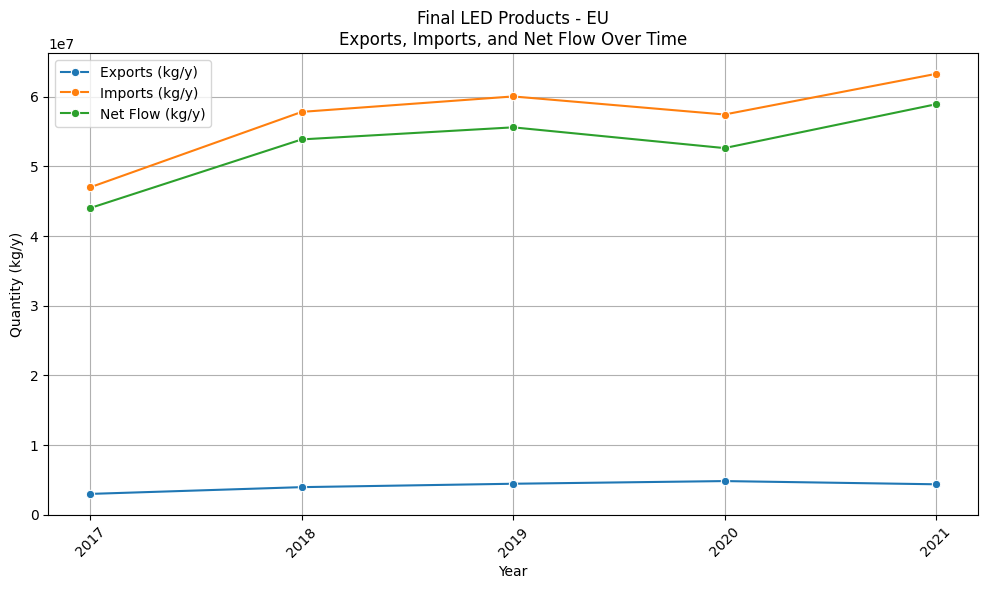

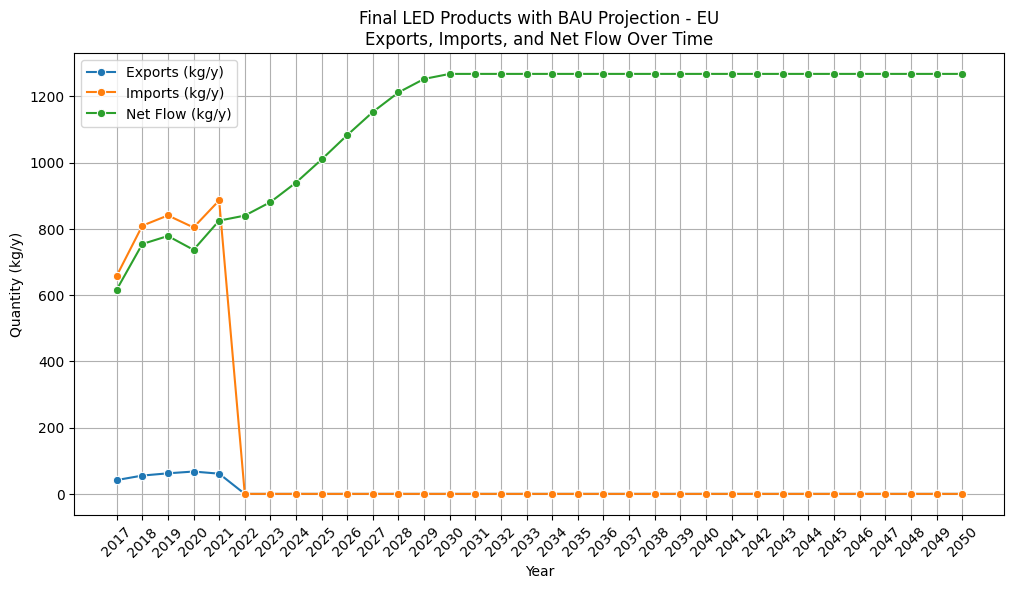

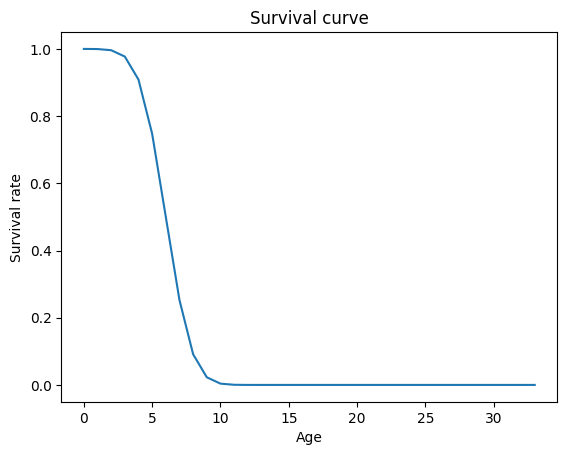

year,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
year,,,,,,,,,,,,,,,,,,,,,
2017,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0
2018,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0
2019,0.996,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0
2020,0.977,0.996,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0
2021,0.909,0.977,0.996,1.000,1.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0
2022,0.748,0.909,0.977,0.996,1.000,1.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0
2023,0.500,0.748,0.909,0.977,0.996,1.000,1.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0
2024,0.252,0.500,0.748,0.909,0.977,0.996,1.000,1.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0
2025,0.091,0.252,0.500,0.748,0.909,0.977,0.996,1.000,1.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0


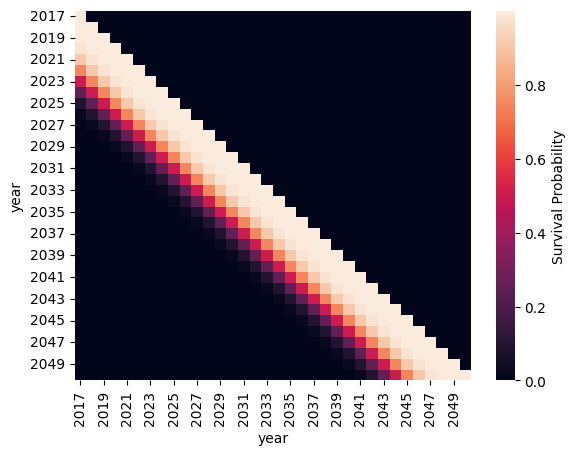

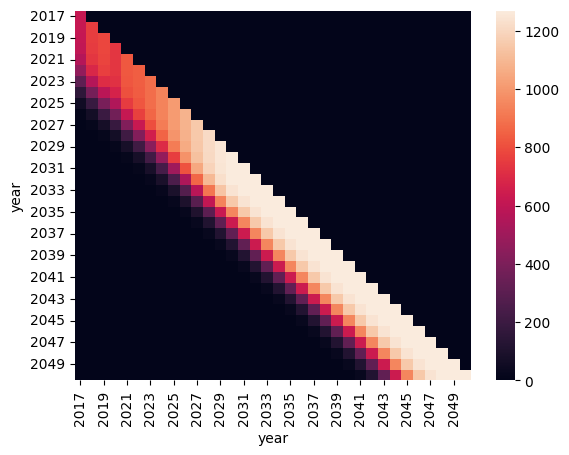

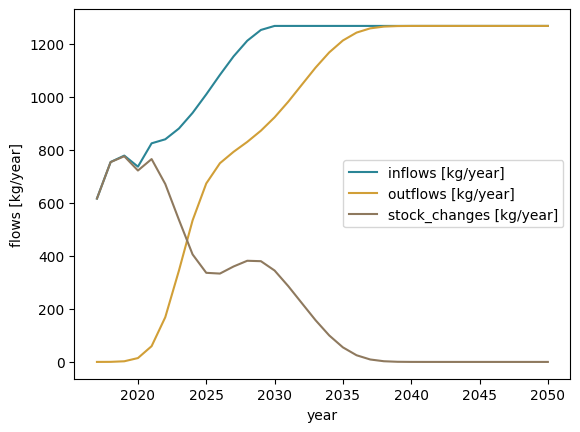

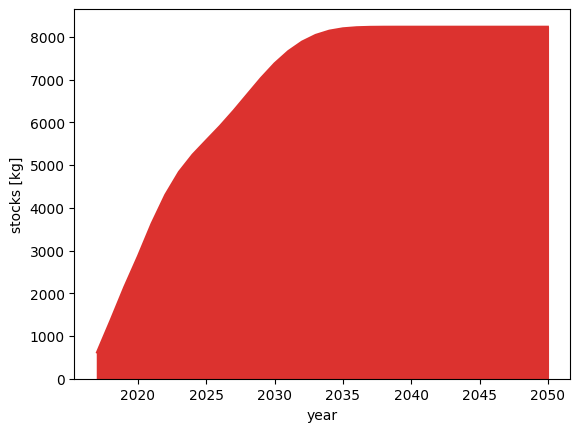

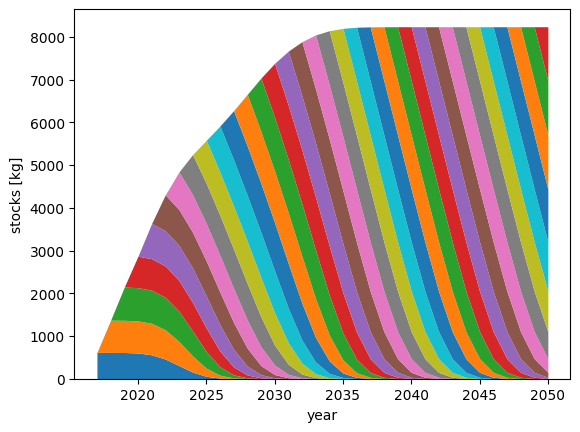

,stocks [kg],inflows [kg/year],outflows [kg/year],stock_changes [kg/year]
year,,,,
2017,616.285485,616.305004,0.019519,6.162855e+02
2018,1370.147170,754.130482,0.268797,7.538617e+02
2019,2146.068555,778.341970,2.420585,7.759214e+02
2020,2868.161269,736.650726,14.558012,7.220927e+02
2021,3633.450882,824.716732,59.427119,7.652896e+02
2022,4304.742266,839.904417,168.613032,6.712914e+02
2023,4840.792261,880.607412,344.557417,5.360500e+02
2024,5246.331031,939.535628,533.996858,4.055388e+02
2025,5582.472813,1009.398978,673.257196,3.361418e+02


In [ ]:
add_normal_survival_curve_to_all_products(product_info)
final_LED_imp_exp_table = build_imp_exp_table(
    eurostat_df, product_info["final_LED"]["product"]
)
final_LED_Ga_imp_exp_table = translate_to_Ga_MI(
    final_LED_imp_exp_table, product_info["final_LED"]["material_intensity_Ga"]
)
plot_imp_exp_table(final_LED_imp_exp_table, "Final LED Products")
# final_LED_Ga_imp_exp_table_with_projection = add_future_BAU_projection(final_LED_Ga_imp_exp_table, growth_rate=0, end_year=2050)
final_LED_Ga_imp_exp_table_with_projection = add_LED_BAU_projection(
    final_LED_Ga_imp_exp_table
)
plot_imp_exp_table(
    final_LED_Ga_imp_exp_table_with_projection, "Final LED Products with BAU Projection"
)
calculate_flow_driven_MFA(
    final_LED_Ga_imp_exp_table_with_projection,
    show_output=True,
    survival_curve_parameters=product_info["final_LED"]["survival_curve_parameters"],
)

In [ ]:
# Plot product "81129289" and indicators "QUANTITY_IN_100KG" with "TIME_PERIOD" on x-axis and "OBS_VALUE" on y-axis, colored by "flow"
# Plot two seperate for partner = "EXT_EU27_2020" and partner = "INT_EU27_2020" => With different legends and colors and markers
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=eurostat_df[
        (eurostat_df["product"] == 81129289)
        & (eurostat_df["indicators"] == "QUANTITY_IN_100KG")
        & (eurostat_df["partner"] == "EXT_EU27_2020")
    ],
    x="TIME_PERIOD",
    y="OBS_VALUE",
    hue="FLOW",
    marker="o",
    linestyle="-",
    palette="Set1",
)
# sns.lineplot(data=eurostat_df[(eurostat_df["product"] == 81129289) & (eurostat_df["indicators"] == "QUANTITY_IN_100KG") & (eurostat_df["partner"] == "INT_EU27_2020")],
#              x="TIME_PERIOD", y="OBS_VALUE", hue="FLOW", marker="s", linestyle="--", palette="Set2")
# Calculate and Plot the difference between FLOW = "IMPORT" and FLOW = "EXPORT" for partner = "EXT_EU27_2020"
net_import_export = eurostat_df[
    (eurostat_df["product"] == 81129289)
    & (eurostat_df["indicators"] == "QUANTITY_IN_100KG")
    & (eurostat_df["partner"] == "EXT_EU27_2020")
].pivot(index="TIME_PERIOD", columns="FLOW", values="OBS_VALUE")
net_import_export["NET_IMPORT_EXPORT"] = (
    net_import_export["IMPORT"] - net_import_export["EXPORT"]
)
sns.lineplot(
    data=net_import_export,
    x=net_import_export.index,
    y="NET_IMPORT_EXPORT",
    marker="D",
    linestyle=":",
    color="purple",
    label="Net Import-Export",
)
plt.title("Import and Export of Unwrought Gallium for EU")
plt.xlabel("Time Period")
plt.ylabel("OBS_VALUE")
plt.legend(title="Flow")
plt.xticks(rotation=45, ticks=net_import_export.index)
plt.tight_layout()
plt.grid()
plt.show()